# Cost Overrun & Variation Risk

**Atul Iwale · AEC Intelligence Portfolio · executed synthetic-data walkthrough**

> **Decision:** Which packages merit commercial review at 50% assumed progress?

[Case study](https://github.com/AtulIwale/Portfolio/tree/main/projects/06-cost-risk) ·
[Data assumptions](https://github.com/AtulIwale/Portfolio/blob/main/docs/DATA_CARD.md) ·
[Portfolio](https://github.com/AtulIwale/Portfolio)

Read the narrative, tables and saved charts on GitHub; no installation is required to read.
To reproduce, use **Runtime → Run all** in a fresh Colab session. The first cell downloads
the public repository and installs dependencies only in Colab. Locally, install
`requirements-notebooks.txt` and open this notebook from the repository.

All data is fictional. Results demonstrate an analytical approach, not proven client impact.

## 1. Reproducible setup

The notebook verifies the dataset hashes and imports reusable project functions. The
important decisions and calculations remain visible below. Saved outputs were produced
by executing all cells in a fresh Python process with IPython rich output capture.
Local Jupyter kernel sockets were unavailable; the hosted Colab service was not used for validation.

In [1]:
from pathlib import Path
import os, sys, subprocess, tempfile

# Pin the computational source/data so later edits to main do not change this walkthrough.
SOURCE_REV = "363f7edcd6c2357bc167257fce4e36b771b216d6"
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / "aec/features.py").exists()), None)
if ROOT is None:
    ROOT = Path(tempfile.mkdtemp(prefix="aec-portfolio-")) / "Portfolio"
    subprocess.run(["git", "clone", "--quiet", "https://github.com/AtulIwale/Portfolio.git", str(ROOT)], check=True)
    subprocess.run(["git", "-C", str(ROOT), "checkout", "--quiet", SOURCE_REV], check=True)
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-r", str(ROOT / "requirements.txt"), "matplotlib==3.10.8"], check=True)
sys.path.insert(0, str(ROOT)) if str(ROOT) not in sys.path else None
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "2")
os.environ.setdefault("OMP_NUM_THREADS", "2")
print("Source:", SOURCE_REV if IN_COLAB else "local checkout")
print("Data: synthetic only; no client information or credentials required.")

Source: local checkout
Data: synthetic only; no client information or credentials required.


In [2]:
import json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aec.data import load_dataset

tables = load_dataset(ROOT / "data")
manifest = json.loads((ROOT / "data/manifest.json").read_text())
for name, spec in manifest["tables"].items():
    assert hashlib.sha256((ROOT / f"data/{name}.jsonl").read_bytes()).hexdigest() == spec["sha256"], name
plt.rcParams.update({"figure.figsize": (10, 4.8), "figure.dpi": 120,
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": "#2D4653", "text.color": "#2D4653", "axes.titleweight": "bold",
    "axes.prop_cycle": plt.cycler(color=["#3F7285", "#B6A78E", "#2D4653", "#899BA5"])})
FIGURES = ROOT / "outputs/notebook-figures"
FIGURES.mkdir(parents=True, exist_ok=True)
def finish(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES / f"{name}.png", dpi=140, bbox_inches="tight", facecolor="white")
    plt.show()
print(f"Verified {len(tables)} tables / {sum(len(t) for t in tables.values()):,} synthetic rows against manifest hashes.")

Verified 12 tables / 28,682 synthetic rows against manifest hashes.


## 2. Define a decision point instead of predicting with hindsight

I use one 50% progress snapshot per package. Original budget normalises the final-cost
target so that a large package does not dominate every comparison. Original budget remains
a feature and INR error is also reported. Final cost and completion date are labels, never inputs.

Physical progress and outcome cost are fictional extensions. Their availability is not
established by the register documentation. The cost and procurement populations are separate.

In [3]:
from aec.features import cost_features,split_mature,COST_NUM,COST_CAT
from aec.models import pipeline,evaluate_cost
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

f=cost_features(tables)
assert not f.package_id.duplicated().any()
assert f.progress_assumption.eq(.5).all()
display(f[["package_id","snapshot_date","original_budget","actual_ratio","pending_ratio","final_ratio"]].head())
print("Decision snapshots:",len(f),"| known final outcomes:",f.final_ratio.notna().sum())

Decision snapshots: 750 | known final outcomes: 739


,package_id,snapshot_date,original_budget,actual_ratio,pending_ratio,final_ratio
0,WP00000,2019-06-22,8203776.46,0.492330,0.000000,0.807514
1,WP00001,2019-07-25,3530002.75,0.562231,0.000000,1.121287
2,WP00002,2019-07-21,5111316.45,0.540659,0.014962,1.189257
3,WP00003,2019-06-02,1988393.67,0.505316,0.043973,1.100852
4,WP00004,2019-05-30,5477588.31,0.540177,0.000000,1.203829


## 3. Explore only training data before choosing a model

The same time boundaries require outcomes to be known before training/validation cutoffs.
There is one package per fictional commercial project, so projects do not cross partitions.
The scatter plot uses training records only; apparent relationships reflect the generator.

,partition,n,start,end
0,Train,378,2019-05-22,2022-08-20
1,Select,57,2023-01-05,2023-06-11
2,Calibrate,58,2023-06-14,2024-02-11
3,Test,116,2024-07-01,2025-06-25


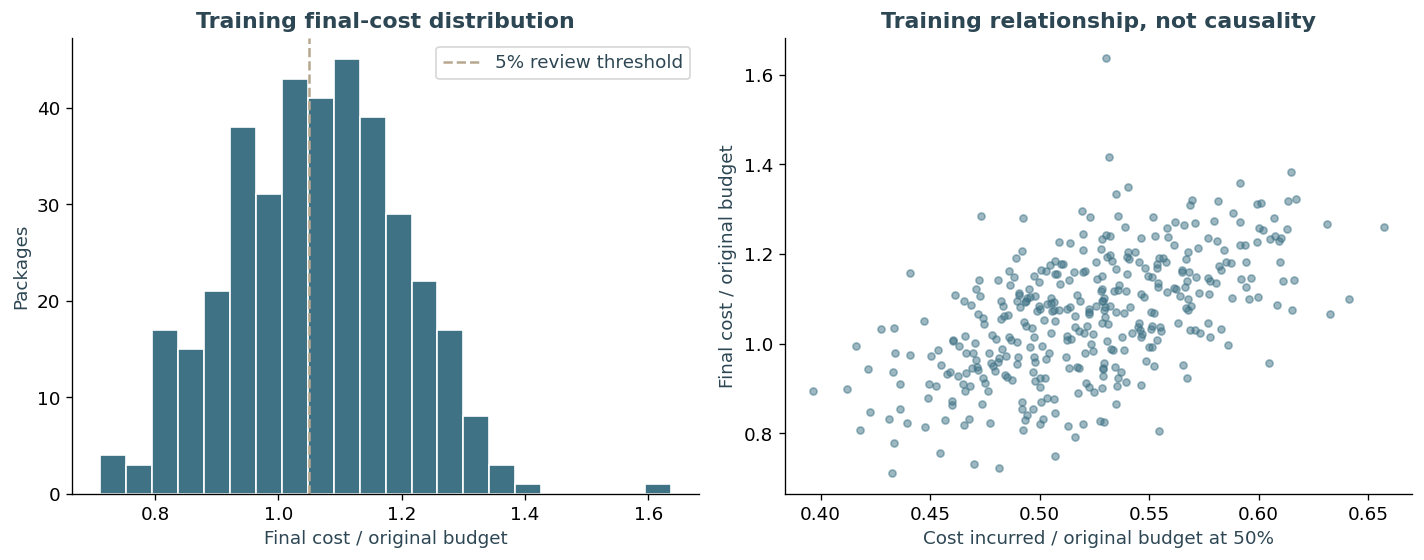

In [4]:
train,val,test=split_mature(f,"snapshot_date","final_ratio")
assert not set(train.project_id)&set(test.project_id)
val=val.sort_values("snapshot_date")
select=val.iloc[:len(val)//2]; calibration=val.iloc[len(val)//2:]
display(pd.DataFrame([{"partition":n,"n":len(p),"start":p.snapshot_date.min(),"end":p.snapshot_date.max()}
    for n,p in [("Train",train),("Select",select),("Calibrate",calibration),("Test",test)]]))
fig,axes=plt.subplots(1,2,figsize=(12,4.8))
axes[0].hist(train.final_ratio,bins=22,color="#3F7285",edgecolor="white")
axes[0].axvline(1.05,color="#B6A78E",linestyle="--",label="5% review threshold")
axes[0].set(title="Training final-cost distribution",xlabel="Final cost / original budget",ylabel="Packages");axes[0].legend()
axes[1].scatter(train.actual_ratio,train.final_ratio,s=18,alpha=.5)
axes[1].set(title="Training relationship, not causality",xlabel="Cost incurred / original budget at 50%",ylabel="Final cost / original budget")
finish(fig,"06-training-exploration")

## 4. Compare baseline, regularised regression and boosting

All preprocessing is trained only on training rows. Median prediction provides the minimum
comparison; ridge limits coefficient size; shallow boosting tests nonlinear patterns. Select
by MAE on the first validation half. Reserve the second half for interval calibration.

In [5]:
cols=COST_NUM+COST_CAT
assert not {"final_cost","final_ratio","completion_date"}.intersection(cols)
candidates={"dummy":DummyRegressor(strategy="median"),"ridge":Ridge(alpha=10),
    "boosting":HistGradientBoostingRegressor(max_iter=100,max_leaf_nodes=7,l2_regularization=3,
        early_stopping=False,random_state=42)}
fitted={name:pipeline(est,COST_NUM,COST_CAT).fit(train[cols],train.final_ratio) for name,est in candidates.items()}
scores={name:mean_absolute_error(select.final_ratio,model.predict(select[cols])) for name,model in fitted.items()}
selected=min(scores,key=scores.get)
display(pd.Series(scores,name="Selection MAE — budget ratio").sort_values().to_frame())
print("Selected before inspecting test:",selected)

Selected before inspecting test: ridge


,Selection MAE — budget ratio
ridge,0.090804
boosting,0.091104
dummy,0.098106


## 5. Show uncertainty, not only one forecast

Absolute residuals from the separate calibration subset define a split-conformal interval.
The finite-sample 90% quantile rounds up. Temporal drift can violate exchangeability, so I
report actual test coverage **and width** rather than promising a 90% guarantee.

,Value
test_MAE_ratio,0.093902
dummy_MAE_ratio,0.121410
test_MAE_INR,354956.972782
nominal_coverage,0.900000
observed_coverage,0.956897
interval_halfwidth_ratio,0.219867


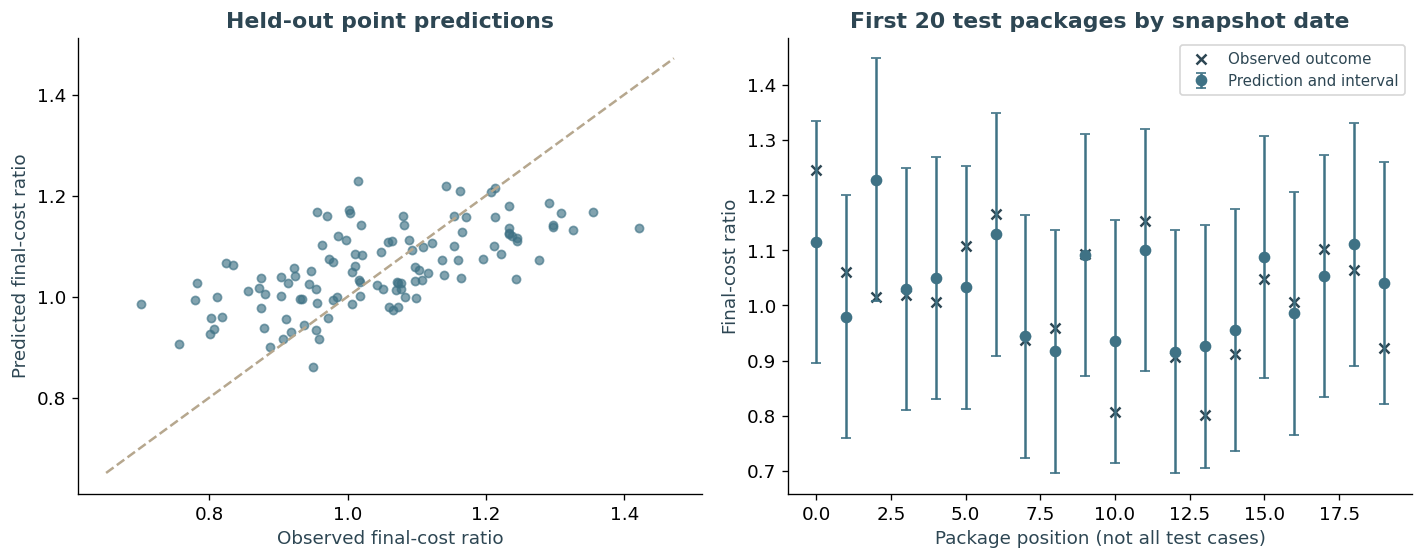

In [6]:
model=fitted[selected]
residual=np.abs(calibration.final_ratio-model.predict(calibration[cols]))
level=min(1,np.ceil((len(calibration)+1)*.9)/len(calibration))
halfwidth=float(np.quantile(residual,level,method="higher"))
prediction=model.predict(test[cols])
coverage=np.mean((test.final_ratio>=prediction-halfwidth)&(test.final_ratio<=prediction+halfwidth))
display(pd.Series({"test_MAE_ratio":mean_absolute_error(test.final_ratio,prediction),
    "dummy_MAE_ratio":mean_absolute_error(test.final_ratio,fitted["dummy"].predict(test[cols])),
    "test_MAE_INR":mean_absolute_error(test.final_cost,prediction*test.original_budget),
    "nominal_coverage":.9,"observed_coverage":coverage,"interval_halfwidth_ratio":halfwidth}).to_frame("Value"))
fig,axes=plt.subplots(1,2,figsize=(12,4.8))
axes[0].scatter(test.final_ratio,prediction,alpha=.65,s=24)
lim=[min(test.final_ratio.min(),prediction.min())-.05,max(test.final_ratio.max(),prediction.max())+.05]
axes[0].plot(lim,lim,linestyle="--",color="#B6A78E")
axes[0].set(title="Held-out point predictions",xlabel="Observed final-cost ratio",ylabel="Predicted final-cost ratio")
ix=np.argsort(test.snapshot_date.to_numpy())[:20]
axes[1].errorbar(range(20),prediction[ix],yerr=halfwidth,fmt="o",capsize=3,label="Prediction and interval")
axes[1].scatter(range(20),test.final_ratio.to_numpy()[ix],marker="x",color="#2D4653",label="Observed outcome")
axes[1].set(title="First 20 test packages by snapshot date",xlabel="Package position (not all test cases)",ylabel="Final-cost ratio");axes[1].legend(fontsize=9)
finish(fig,"06-predictions-intervals")

## 6. Translate the forecast into investigation

A forecast above 105% of original budget creates a review flag. It is not a calibrated overrun
probability and does not approve a budget change. Check pending variations, quantity/rate
assumptions and remaining scope with a commercial owner.

Constant feature check: ['progress_assumption']


,package_id,original_budget,final_cost,predicted_final_cost,lower,upper,investigate_overrun
608,WP00608,3219219.70,4007444.04,3589785.51,2881984.91,4297586.11,True
613,WP00613,584056.76,680785.76,659265.42,530850.53,787680.30,True
615,WP00615,2242440.38,2255464.11,2353408.49,1860369.56,2846447.42,False
617,WP00617,2820874.49,2644857.97,2663124.77,2042907.19,3283342.34,False
620,WP00620,2509909.50,2781343.40,2592203.39,2040356.79,3144049.99,False
621,WP00621,2121457.11,2318600.99,2315352.00,1848913.31,2781790.69,True
624,WP00624,4105129.95,4528841.19,4323202.69,3420619.54,5225785.83,True
625,WP00625,3034426.62,3053344.67,2990330.29,2323159.61,3657500.96,False


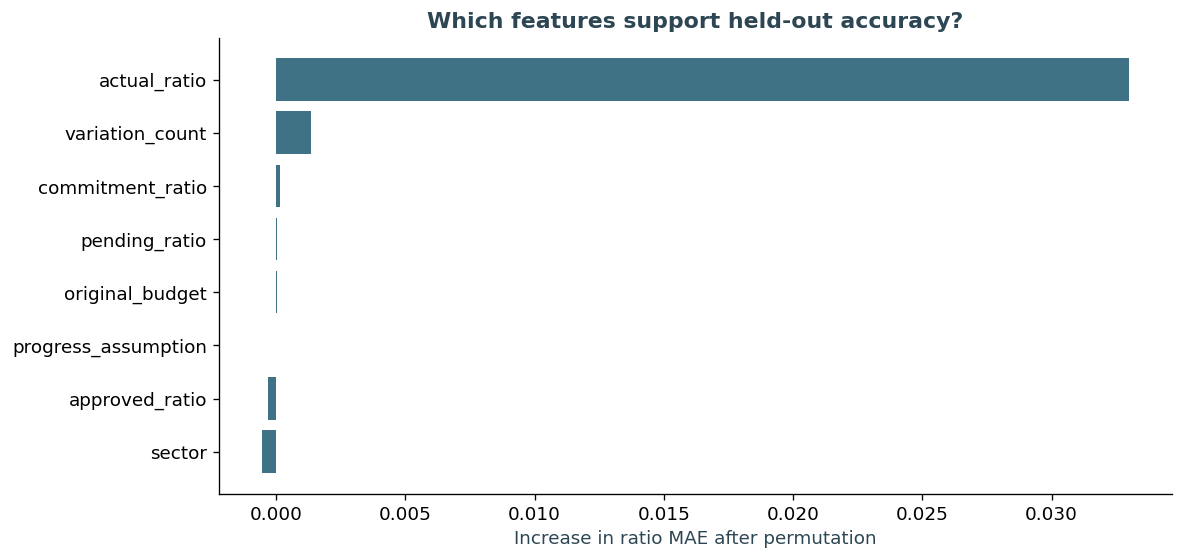

In [7]:
report,queue=evaluate_cost(f)
assert report["selected_model"]==selected
assert np.isclose(report["test_mae_ratio"],mean_absolute_error(test.final_ratio,prediction))
display(queue.head(8).round(2))
importance=pd.Series(report["permutation_importance"]).sort_values()
fig,ax=plt.subplots()
ax.barh(importance.index,importance.values)
ax.set(title="Which features support held-out accuracy?",xlabel="Increase in ratio MAE after permutation")
finish(fig,"06-importance")
print("Constant feature check:",train[COST_NUM].nunique()[lambda x:x==1].index.tolist())

## 7. Interpretation and limits

In the committed seed-42 run, ridge beats the median baseline on test MAE. The interval
coverage is high but the interval width is substantial. These are two different aspects of
usefulness: a wide interval can cover many outcomes without supporting a precise decision.

Assumed progress is constant because this model uses only the 50% milestone; it contributes
no discrimination here. Permutation importance is not proof of causal cost drivers, especially
with correlated cost features. Next iteration could remove constants without changing the
prediction-time contract, then validate on a newly held-out period.

Before production: reconcile actual cost records, verify physical progress and remaining
scope, broaden the project population and conduct prospective commercial review. No real
cost-overrun reduction or savings has been demonstrated.

**Interview discussion:** Why a budget ratio and an INR metric? Why separate selection from
calibration? Why does high coverage not make a forecast precise? Why is an overrun flag not a probability?